# Análise de Cohort para Retenção de Clientes

Este notebook realiza a análise de cohort para entender a retenção de clientes ao longo do tempo, utilizando o dataset Online Retail II.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import os
import config

## 1. Carregar o dataset

In [6]:
# Carregar o dataset
try:
    file_path = os.path.join(config.PATH, 'online_retail_II.csv')
    df = pd.read_csv(file_path)
    print("Dataset carregado com sucesso!")
    display(df.head())
except FileNotFoundError:
    print(f"Arquivo não encontrado em: {file_path}")

Dataset carregado com sucesso!


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Limpeza dos Dados

In [7]:
# Verificar nulos
print("Nulos antes da limpeza:")
print(df.isnull().sum())

# Remover nulos (especialmente Customer ID)
df = df.dropna(subset=['Customer ID'])

# Remover cancelamentos (Invoice contendo 'C')
df = df[~df['Invoice'].astype(str).str.contains('C')]

# Remover valores negativos ou zerados em Quantity e Price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Converter InvoiceDate para datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Converter Customer ID para inteiro
df['Customer ID'] = df['Customer ID'].astype(int)

print("\nDimensões após limpeza:", df.shape)

Nulos antes da limpeza:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Dimensões após limpeza: (805549, 8)


## FASE 1: Definição de Cohort
Nesta fase, vamos:
1. Identificar o mês da transação (`TransactionMonth`).
2. Identificar o mês da primeira compra de cada cliente (`CohortMonth`).
3. Calcular a idade do cohort (`CohortIndex`), que representa o número de meses desde a primeira compra.

In [8]:
# Função para obter o primeiro dia do mês
def get_month(x):
    return dt.datetime(x.year, x.month, 1)

# Criar coluna TransactionMonth
df['TransactionMonth'] = df['InvoiceDate'].apply(get_month)

# Identificar CohortMonth (mês da primeira compra para cada cliente)
grouping = df.groupby('Customer ID')['TransactionMonth']
df['CohortMonth'] = grouping.transform('min')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TransactionMonth,CohortMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-12-01,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12-01,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12-01,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-12-01,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-12-01,2009-12-01


In [9]:
# Função para extrair ano, mês e dia
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    day = df[column].dt.day
    return year, month, day

# Extrair ano e mês
invoice_year, invoice_month, _ = get_date_int(df, 'TransactionMonth')
cohort_year, cohort_month, _ = get_date_int(df, 'CohortMonth')

# Calcular a diferença em anos e meses
years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

# Calcular CohortIndex (idade do cohort em meses, começando de 1)
df['CohortIndex'] = years_diff * 12 + months_diff + 1

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TransactionMonth,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-12-01,2009-12-01,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12-01,2009-12-01,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12-01,2009-12-01,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-12-01,2009-12-01,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-12-01,2009-12-01,1


## FASE 2: Tabela de Contagem e Pivotamento
Nesta fase, vamos:
1. Contagem de Clientes (Agrupar o dataframe pela coluna CohortMonth e CohortIndex e conte o número de CustomerID únicos em cada grupo)
2. Pivotamento da Tabela (Transformar a tabela de contagem em um formato de planilha (Pivot Table), onde as linhas são os CohortMonth e as colunas são o CohortIndex)
3. Cálculo da Retenção (Dividir o número de clientes em cada célula pelo número de clientes no Mês 0 (tamanho inicial do cohort). Multiplique por 100 para obter a porcentagem)

In [ ]:
# 1. Contagem de Clientes
# Agrupar por CohortMonth e CohortIndex e contar Customer IDs únicos
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique()

# Resetar o índice para transformar em DataFrame
cohort_data = cohort_data.reset_index()

# Renomear a coluna para melhor entendimento
cohort_data.rename(columns={'Customer ID': 'NumCustomers'}, inplace=True)

print("Dados de cohort agrupados:")
display(cohort_data.head(20))

Dados de cohort agrupados:


,CohortMonth,CohortIndex,NumCustomers
0,2009-12-01,1,955
1,2009-12-01,2,337
2,2009-12-01,3,319
3,2009-12-01,4,406
4,2009-12-01,5,363
5,2009-12-01,6,343
6,2009-12-01,7,360
7,2009-12-01,8,327
8,2009-12-01,9,321
9,2009-12-01,10,346


In [11]:
# 2. Pivotamento da Tabela
# Transformar em pivot table: linhas = CohortMonth, colunas = CohortIndex
cohort_counts = cohort_data.pivot(index='CohortMonth', 
                                   columns='CohortIndex', 
                                   values='NumCustomers')

print("Tabela pivotada - Contagem de clientes por cohort:")
display(cohort_counts)

Tabela pivotada - Contagem de clientes por cohort:


CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12-01,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02-01,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03-01,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04-01,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05-01,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06-01,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# 3. Cálculo da Retenção
# Dividir cada célula pelo valor do Mês 1 (primeira coluna) e multiplicar por 100
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

print("Taxa de Retenção (%):\n")
display(retention.round(1))

# Estatísticas básicas
print("\nEstatísticas da taxa de retenção:")
print(retention.describe().round(1))

Taxa de Retenção (%):



CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12-01,100.0,35.3,33.4,42.5,38.0,35.9,37.7,34.2,33.6,36.2,...,30.3,26.3,30.3,28.3,26.0,25.5,31.5,30.5,40.7,19.7
2010-01-01,100.0,20.6,31.1,30.5,26.4,30.0,25.8,23.0,27.9,31.9,...,15.1,23.5,19.8,18.5,19.6,24.3,19.3,24.5,5.7,NaN
2010-02-01,100.0,23.8,22.5,29.1,24.6,20.1,19.3,28.6,25.4,27.5,...,20.1,16.0,16.3,14.4,23.0,23.0,16.3,5.9,NaN,NaN
2010-03-01,100.0,19.0,23.0,24.2,23.3,20.3,24.6,30.2,27.5,10.8,...,16.9,17.4,15.6,17.6,20.1,21.2,7.9,NaN,NaN,NaN
2010-04-01,100.0,19.4,19.4,16.3,18.4,22.4,27.6,26.2,10.5,10.9,...,15.6,13.9,15.0,18.0,22.4,5.8,NaN,NaN,NaN,NaN
2010-05-01,100.0,15.7,16.9,17.3,17.7,25.6,21.3,12.6,5.9,8.3,...,12.6,13.8,16.5,15.4,4.7,NaN,NaN,NaN,NaN,NaN
2010-06-01,100.0,17.4,18.9,20.4,23.0,28.5,12.6,8.9,8.1,11.9,...,12.2,13.3,20.4,5.2,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,100.0,15.6,18.3,29.6,29.0,14.0,11.3,14.5,14.5,11.3,...,17.2,23.7,8.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,100.0,20.4,29.6,32.1,17.3,11.7,9.9,12.3,13.6,13.0,...,19.8,6.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Estatísticas da taxa de retenção:
CohortIndex     1     2     3     4     5     6     7     8     9     10  ...  \
count         25.0  24.0  23.0  22.0  21.0  20.0  19.0  18.0  17.0  16.0  ...   
mean         100.0  21.2  21.9  21.6  20.5  18.8  17.8  17.7  15.6  15.3  ...   
std            0.0   5.9   7.7   8.3   7.7   8.1   8.0   8.2   8.6   9.3  ...   
min          100.0   9.2   5.3   9.2   7.7   6.6   5.3   8.9   5.3   2.6  ...   
25%          100.0  17.3  17.6  16.2  17.3  13.4  12.8  11.9  10.5   9.4  ...   
50%          100.0  20.5  21.3  20.0  21.1  17.9  15.5  14.2  12.8  11.6  ...   
75%          100.0  24.2  27.0  27.3  23.3  24.1  22.9  24.8  24.0  18.6  ...   
max          100.0  35.3  37.6  42.5  38.0  35.9  37.7  34.2  33.6  36.2  ...   

CohortIndex    16    17    18    19    20    21    22    23    24    25  
count        10.0   9.0   8.0   7.0   6.0   5.0   4.0   3.0   2.0   1.0  
mean         16.5  17.2  17.7  16.8  19.3  20.0  18.8  20.3  23.2  19.7  
std          

In [13]:
retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12-01,100.0,35.287958,33.403141,42.513089,38.010471,35.916230,37.696335,34.240838,33.612565,36.230366,...,30.261780,26.282723,30.261780,28.272251,25.968586,25.549738,31.518325,30.471204,40.732984,19.685864
2010-01-01,100.0,20.626632,31.070496,30.548303,26.370757,30.026110,25.848564,22.976501,27.937337,31.853786,...,15.143603,23.498695,19.843342,18.537859,19.582245,24.281984,19.321149,24.543081,5.744125,NaN
2010-02-01,100.0,23.796791,22.459893,29.144385,24.598930,20.053476,19.251337,28.609626,25.401070,27.540107,...,20.053476,16.042781,16.310160,14.438503,22.994652,22.994652,16.310160,5.882353,NaN,NaN
2010-03-01,100.0,18.961625,23.024831,24.153499,23.250564,20.316027,24.604966,30.248307,27.539503,10.835214,...,16.930023,17.381490,15.575621,17.607223,20.090293,21.218962,7.900677,NaN,NaN,NaN
2010-04-01,100.0,19.387755,19.387755,16.326531,18.367347,22.448980,27.551020,26.190476,10.544218,10.884354,...,15.646259,13.945578,14.965986,18.027211,22.448980,5.782313,NaN,NaN,NaN,NaN


## FASE 3: Visualização (Heatmap)
Nesta fase, vamos:
1. Preparação da Matriz para Visualização
2. Geração do Mapa de Calor (Heatmap)

CohortMonth
Dec-09    100.0
Jan-10    100.0
Feb-10    100.0
Mar-10    100.0
Apr-10    100.0
May-10    100.0
Jun-10    100.0
Jul-10    100.0
Aug-10    100.0
Sep-10    100.0
Oct-10    100.0
Nov-10    100.0
Dec-10    100.0
Jan-11    100.0
Feb-11    100.0
Mar-11    100.0
Apr-11    100.0
May-11    100.0
Jun-11    100.0
Jul-11    100.0
Aug-11    100.0
Sep-11    100.0
Oct-11    100.0
Nov-11    100.0
Dec-11    100.0
Name: 1, dtype: float64

In [23]:
#try:
#    retention.index = pd.to_datetime(retention.index, format='%Y-%m-%d')
#except ValueError:
    # Se falhar, tenta o formato YYYY-MM
#    retention.index = pd.to_datetime(retention.index, format='%Y-%m')
retention.index = pd.to_datetime(retention.index, format='%b-%y', errors='coerce')

# Garante que os nomes do eixo Y estejam formatados corretamente (ex: Jan-10)
retention.index = retention.index.strftime('%b-%y')

# Remova o índice 0 (100%) da visualização, pois ele não acrescenta informação
plot_data = retention.drop(columns=[1])

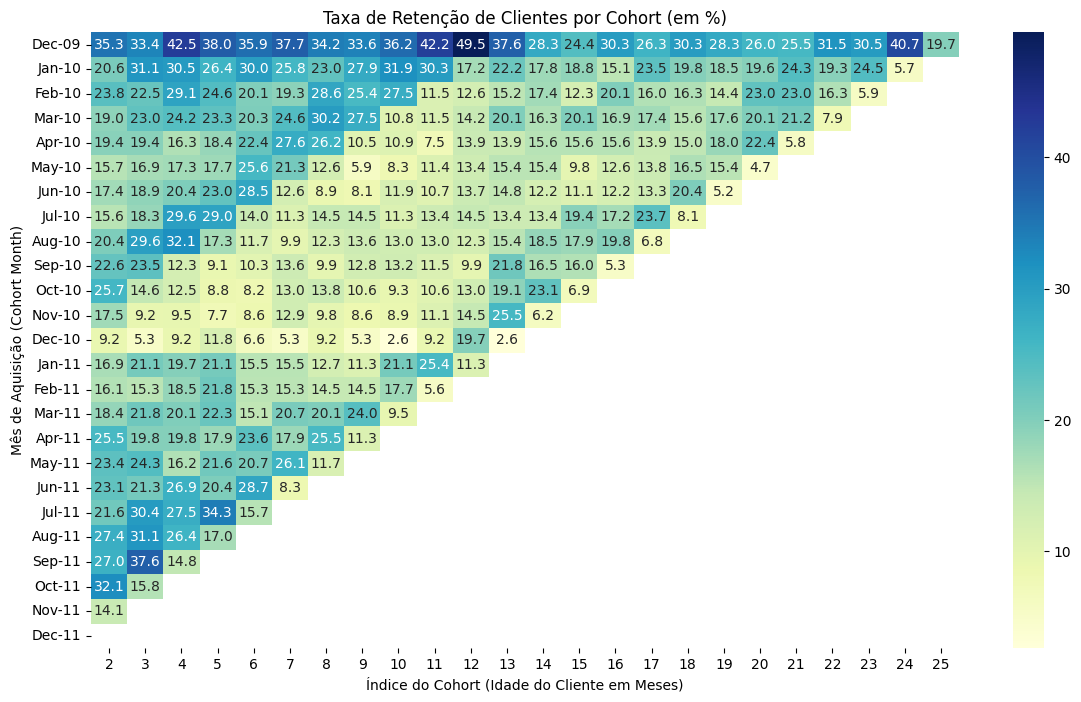

In [24]:
# Geração do Mapa de Calor (Heatmap)
plt.figure(figsize=(14, 8))
sns.heatmap(
    plot_data, 
    annot=True, # Adicionar o valor numérico em cada célula
    fmt='.1f', # Formatar com uma casa decimal (ex: 35.3)
    cmap='YlGnBu', # Esquema de cores: Amarelo-Verde-Azul
    cbar=True # Mostrar a barra lateral de cor
)

plt.title('Taxa de Retenção de Clientes por Cohort (em %)')
plt.ylabel('Mês de Aquisição (Cohort Month)')
plt.xlabel('Índice do Cohort (Idade do Cliente em Meses)')
plt.show()

## FASE 4: Conclusões


Excelente! A imagem que você gerou, o Mapa de Calor da Taxa de Retenção de Clientes por Cohort, é uma das visualizações mais valiosas para qualquer stakeholder.

As conclusões devem ser traduzidas diretamente em oportunidades de receita, custo e qualidade de clientes.

🔍 Conclusões e Insights do Heatmap de Retenção
A análise se concentra em três áreas: Qualidade da Aquisição (Colunas Iniciais), Retenção de Longo Prazo (Colunas Finais) e Anormalidades (Picos/Quedas).

1. Qualidade da Aquisição (Retenção Inicial)
O foco está nas colunas 2 e 3 (Mês 1 e Mês 2 após a primeira compra). A retenção inicial reflete a qualidade da campanha de aquisição e a satisfação imediata do cliente.

🏆 Cohort de Maior Qualidade:

Dez-09 e Jan-11 são os cohorts mais fortes, com retenção no Mês 2 acima de 25% e que se mantém em patamares elevados.

Valor para o Negócio: Sugere que as campanhas de marketing, o mix de produtos, ou as condições de mercado em Dezembro de 2009 e Janeiro de 2011 trouxeram clientes mais adequados. A recomendação é diagnosticar e replicar a estratégia de aquisição desses períodos para reduzir o Custo de Aquisição (CAC) de clientes de baixa qualidade.

🚨 Cohort de Baixa Qualidade (Risco Imediato):

Mai-10 (15.7% no Mês 2) e Nov-10 (9.2% no Mês 2) apresentam quedas muito rápidas.

Valor para o Negócio: O dinheiro gasto para adquirir esses clientes teve um baixo Retorno sobre o Investimento (ROI). A recomendação é investigar se houve falhas na landing page, erros de logística ou aquisição de clientes via canais de baixa conversão nesses meses.

2. Retenção de Longo Prazo e Taxa de Estabilização
O foco está nas colunas 8 em diante. Onde as cores se estabilizam, o negócio encontra sua Taxa de Retenção Sustentável.

🎯 Estabilização Geral: A taxa de retenção da maioria dos cohorts tende a se estabilizar em torno de 10% a 15% após o Mês 6.

✨ Destaque de Longa Duração: O cohort Dez-09 demonstra retenção excepcional, mantendo-se acima de 25% até o Mês 18 e atingindo um pico notável de 40.7% no Mês 25.

Valor para o Negócio: A retenção de longo prazo é o principal motor do Valor Vitalício do Cliente (CLV). A análise deve determinar se essa longevidade se deve a um programa de fidelidade forte ou a um nicho de clientes muito engajado.

3. Anormalidades e Ações Diagnósticas (Picos e Quedas)
Procure por células que se destacam muito em relação aos vizinhos.

📈 Picos de Reativação:

Dez-10 (de 9.5% para 26.2% no Mês 12).

Jan-11 (de 12.7% para 25.4% no Mês 12).

Valor para o Negócio: Os picos de retenção que ocorrem exatamente no Mês 12 (especialmente em Dez-10/Jan-11) sugerem a ocorrência de uma campanha de reativação anual eficaz ou um evento sazonal (Natal, Ano Novo) que traz clientes antigos de volta. Isso prova que a reativação funciona se for feita no momento certo.

📉 Quedas Inexplicadas:

O cohort Set-10 (22.6% no Mês 3, mas apenas 6.8% no Mês 6).

Valor para o Negócio: Essas quedas repentinas exigem uma Análise Diagnóstica (o seu próximo projeto!). A empresa precisa descobrir: Houve um erro no envio de e-mail? A qualidade do produto piorou? Isso indica uma falha no relacionamento pós-venda.